In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# load data
dataset_name = "lung-cancer-clinical-dataset-20152025"
file = "lung_cancer_dataset.csv"
df = pd.read_csv("/".join(["../data/raw/", 
                                              dataset_name, file]))

In [3]:
# clean and prepare data
X = df.drop('Survived', axis=1)

y = df.loc[:, 'Survived']

#train-test split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=0,
                                                    stratify=y)
# save as csv files
X_train.to_csv(path_or_buf="../data/processed/X_train.csv")
y_train.to_csv(path_or_buf="../data/processed/y_train.csv")
X_test.to_csv(path_or_buf="../data/processed/X_test.csv")
y_test.to_csv(path_or_buf="../data/processed/y_test.csv")

In [4]:
df = X_train.copy()

In [5]:
# dropping columns with no predictive power
df = df.drop(['Patient_ID', 'Diagnosis_Year', 'Diagnosis_Date',
              'Survival_Months'], axis=1)

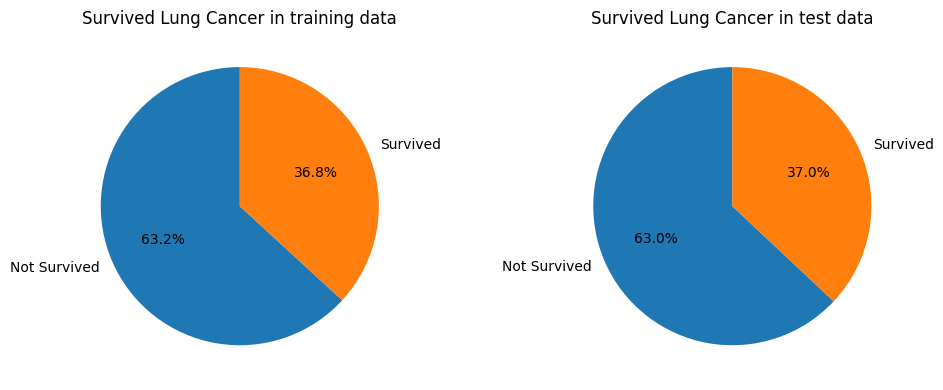

In [6]:
# visualising the distribution in target columns
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Training data plot
survived = pd.crosstab(index=y_train, columns='count', normalize='columns')
survived.plot(kind='pie',
                y='count',
                labels=['Not Survived', 'Survived'],
                autopct='%1.1f%%',
                legend=False,
                startangle=90,
                title='Survived Lung Cancer in training data',
                ax=axs[0])
axs[0].set_ylabel('')

# Test data plot
survived = pd.crosstab(index=y_test, columns='count', normalize='columns')
survived.plot(kind='pie',
                y='count',
                labels=['Not Survived', 'Survived'],
                autopct='%1.1f%%',
                legend=False,
                startangle=90,
                title='Survived Lung Cancer in test data',
                ax=axs[1])
axs[1].set_ylabel('')

plt.tight_layout()
plt.show()

decided not to resample,because tree-based models like random forest will handle it through "class_weights='balanced'"

In [7]:
def clean_data(features):
    features = features.drop(['Patient_ID', 'Diagnosis_Year', 
                              'Diagnosis_Date', 'Survival_Months'], axis=1)
    return features

# Feature Engineering

In [8]:
# adding pack_years as a feature (a standard clinical metric)
df.loc[:, 'Pack_Years'] = (df.loc[:, 'Cigarettes_Per_Day'] / 20) * df.loc[:, 'Years_Smoking']

df.loc[:, 'Pack_Years'].sample(5)

1146    49.30
183     37.95
313      0.00
826      0.00
115      0.00
Name: Pack_Years, dtype: float64

In [9]:
# changing cancer stage to ordinal values
stage_map = {'Stage I': 1,
             'Stage II': 2,
             'Stage III': 3,
             'Stage IV': 4}
df.loc[:, 'Cancer_Stage_Numeric'] = df.loc[:, 'Cancer_Stage'].map(stage_map)
df.loc[:, 'Cancer_Stage_Numeric'].sample(5)

904     1
219     3
1327    4
938     1
674     2
Name: Cancer_Stage_Numeric, dtype: int64

In [ ]:
# changing binary values to 1 and 0
binary_cols = ['Secondhand_Smoke', 'Family_History', 'Occupational_Hazard',
            'Chronic_Lung_Disease', 'Asbestos_Exposure', 'Radon_Exposure',
            'Previous_Cancer_History', 'Coughing','Shortness_of_Breath', 
            'Chest_Pain', 'Coughing_Blood', 'Fatigue', 'Weight_Loss', 
            'Wheezing', 'Recurrent_Infections', 'Swallowing_Difficulty', 
            'Finger_Clubbing', 'Metastasis']

df[binary_cols] = df[binary_cols].eq('Yes').astype(int)
df.loc[:, binary_cols].sample(5)

C:\Users\Jaeden Capinig\AppData\Local\Temp\ipykernel_23164\601370863.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[:, binary_cols] = df.loc[:, binary_cols].replace({'Yes': 1, 'No':0})


,Secondhand_Smoke,Family_History,Occupational_Hazard,Chronic_Lung_Disease,Asbestos_Exposure,Radon_Exposure,Previous_Cancer_History,Coughing,Shortness_of_Breath,Chest_Pain,Coughing_Blood,Fatigue,Weight_Loss,Wheezing,Recurrent_Infections,Swallowing_Difficulty,Finger_Clubbing,Metastasis
976,0,1,1,0,0,0,1,1,0,0,0,1,0,1,0,0,0,1
581,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0
1148,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0
1390,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0
1272,1,1,0,0,0,1,0,1,0,0,0,1,1,0,0,0,0,0


In [ ]:
# converting gender values
df['Gender'] = df['Gender'].eq('Male').astype(int)
# converting cancer types
df['Cancer_Type'] = df['Cancer_Type'].eq('NSCLC').astype(int)

In [12]:
display(df['Gender'])
display(df['Cancer_Type'])

916     1
1170    1
113     1
296     0
808     0
       ..
1461    0
962     1
801     1
697     0
503     1
Name: Gender, Length: 1200, dtype: int64

916     1
1170    1
113     1
296     1
808     1
       ..
1461    1
962     0
801     1
697     1
503     1
Name: Cancer_Type, Length: 1200, dtype: int64

In [16]:
# creating a count column for symptoms and risk
symptom_cols = ['Coughing','Shortness_of_Breath', 'Chest_Pain', 'Coughing_Blood', 
                'Fatigue', 'Weight_Loss', 'Wheezing', 'Recurrent_Infections', 
                'Swallowing_Difficulty', 'Finger_Clubbing', 'Metastasis']

df['Symptom_Count'] = df[symptom_cols].sum(axis=1).astype(int)
display(df.loc[:, 'Symptom_Count'].sample(5))

risk_cols = ['Secondhand_Smoke', 'Family_History', 'Occupational_Hazard',
            'Chronic_Lung_Disease', 'Asbestos_Exposure', 'Radon_Exposure',
            'Previous_Cancer_History']

df['Risk_Count'] = df[risk_cols].sum(axis=1).astype(int)
display(df.loc[:, 'Risk_Count'].sample(5))


683     4
1087    2
797     3
1385    4
379     3
Name: Symptom_Count, dtype: int64

131     0
575     2
540     0
614     3
1490    1
Name: Risk_Count, dtype: int64

In [18]:
def engineer_X(X):
    # adding pack_years as a feature (a standard clinical metric)
    X['Pack_Years'] = (X['Cigarettes_Per_Day'] / 20) * X['Years_Smoking']

    # changing cancer stage to ordinal values
    stage_map = {'Stage I': 1,
                 'Stage II': 2,
                 'Stage III': 3,
                 'Stage IV': 4}
    X['Cancer_Stage_Numeric'] = X['Cancer_Stage'].map(stage_map)

    # changing binary values to 1 and 0
    binary_cols = ['Secondhand_Smoke', 'Family_History', 'Occupational_Hazard',
                'Chronic_Lung_Disease', 'Asbestos_Exposure', 'Radon_Exposure',
                'Previous_Cancer_History', 'Coughing','Shortness_of_Breath', 
                'Chest_Pain', 'Coughing_Blood', 'Fatigue', 'Weight_Loss', 
                'Wheezing', 'Recurrent_Infections', 'Swallowing_Difficulty', 
                'Finger_Clubbing', 'Metastasis']

    X[binary_cols] = X[binary_cols].eq("Yes").astype(int)

    # converting gender values
    X['Gender'] = X['Gender'].eq("Male").astype(int)
    
    # converting cancer types
    X['Cancer_Type'] = X['Cancer_Type'].eq("NSCLC").astype(int)

    # creating a count column for symptoms and risk
    symptom_cols = ['Coughing','Shortness_of_Breath', 'Chest_Pain', 
                    'Coughing_Blood', 'Fatigue', 'Weight_Loss', 'Wheezing', 
                    'Recurrent_Infections', 'Swallowing_Difficulty', 
                    'Finger_Clubbing', 'Metastasis']
    X['Symptom_Count'] = X[symptom_cols].sum(axis=1).astype(int)

    risk_cols = ['Secondhand_Smoke', 'Family_History', 'Occupational_Hazard',
                'Chronic_Lung_Disease', 'Asbestos_Exposure', 'Radon_Exposure',
                'Previous_Cancer_History']
    X['Risk_Count'] = X[risk_cols].sum(axis=1).astype(int)

    return X


# Dimensionality Reduction

In [ ]:
scaler = StandardScaler()

In [19]:
# read the data again
X = pd.read_csv("/".join(["../data/raw/", 
                                              dataset_name, file]))
X = engineer_X(clean_data(X))
X['Survived'] = X['Survived'].eq("Yes").astype(int)
X['Survived'].sample(5)

30     0
185    0
864    0
952    1
57     0
Name: Survived, dtype: int64

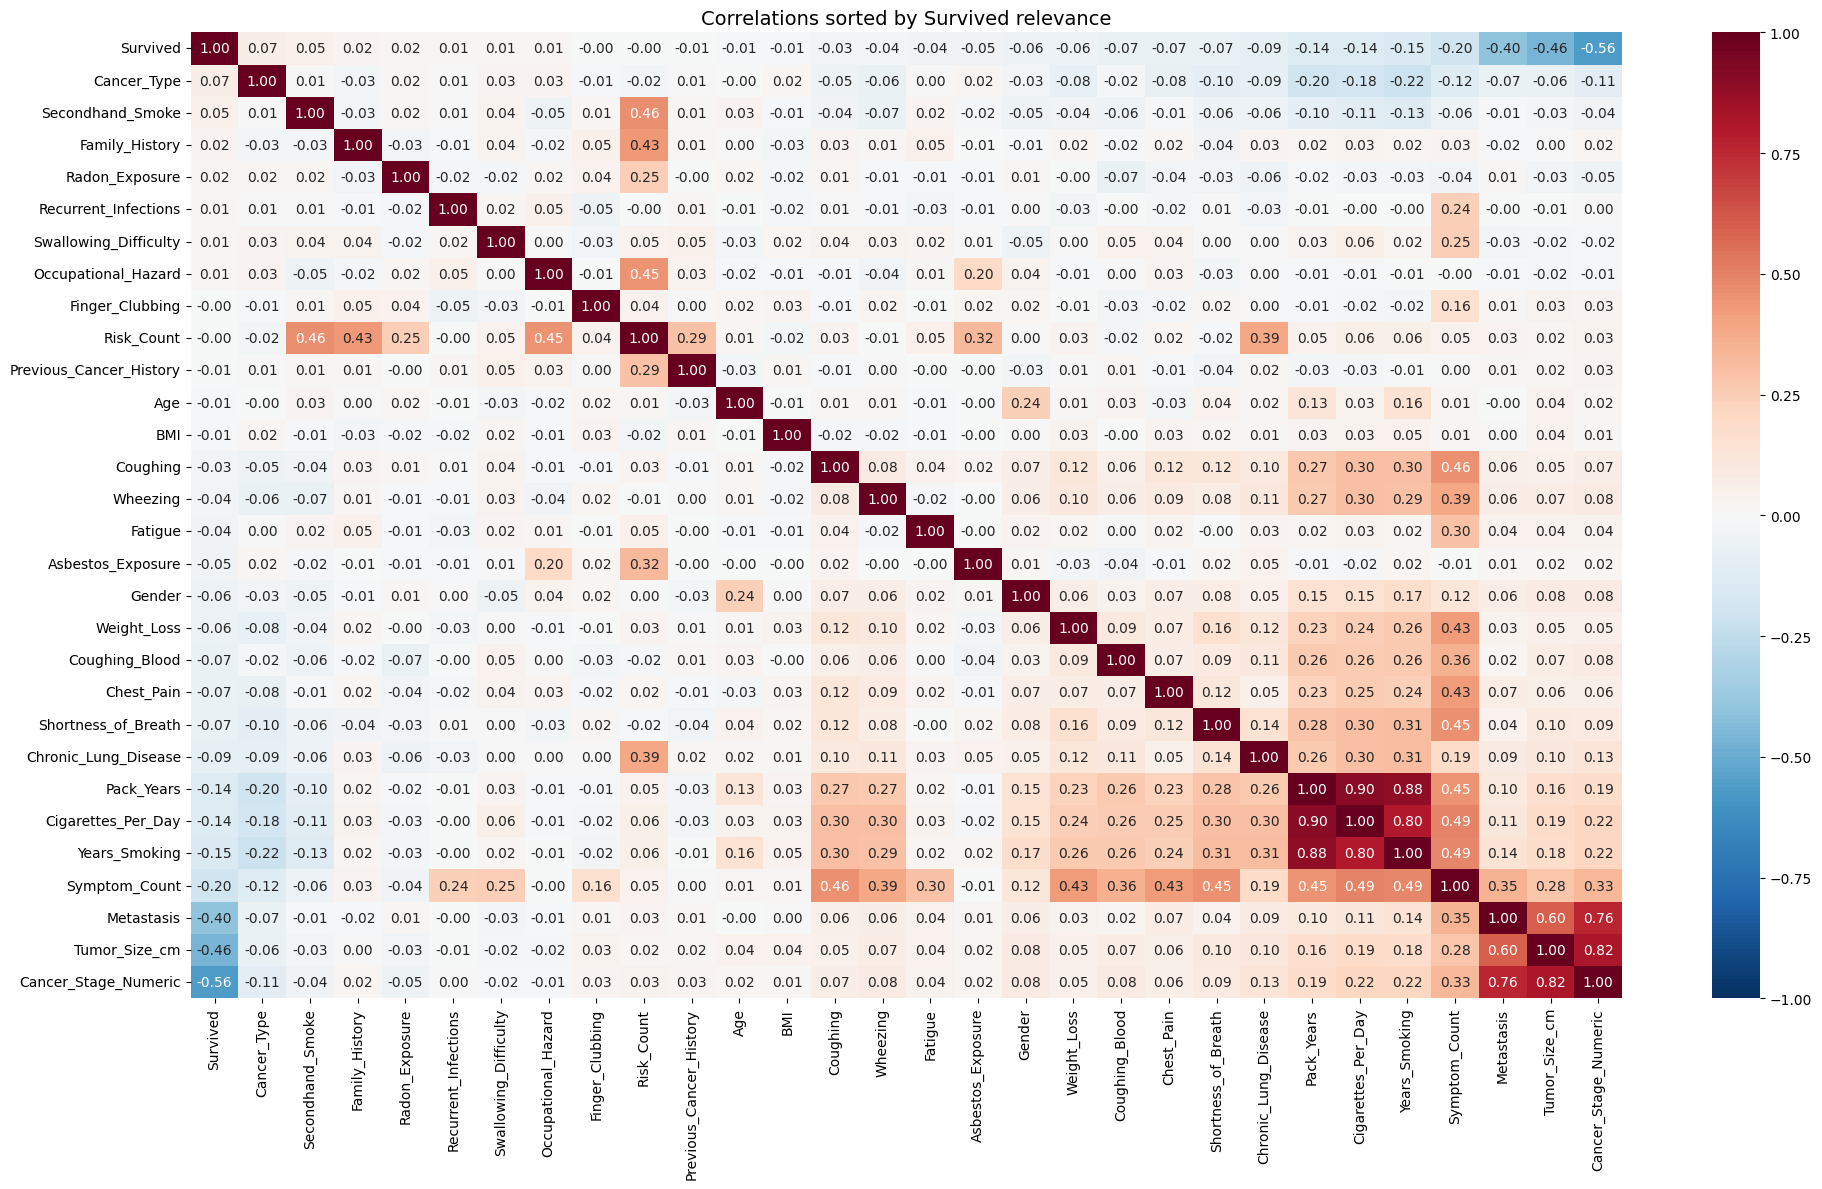

In [20]:
# Correlations sorted by relationship to Survived
corr = X.corr(numeric_only=True)
target_corr = corr['Survived'].sort_values(ascending=False)
sorted_cols = target_corr.index

corr_sorted = corr.loc[sorted_cols, sorted_cols]

plt.figure(figsize=(20, 12))
sns.heatmap(corr_sorted, 
            annot=True, 
            fmt='.2f',
            cmap='RdBu_r',  # Diverging: red=positive, blue=negative
            center=0,        # Center colormap at zero
            vmin=-1, 
            vmax=1)

plt.title('Correlations sorted by Survived relevance', fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# removing columns again to reduce correlation instead of using PCA
from pyparsing import col


def engineer_X(X):
    # adding pack_years as a feature (a standard clinical metric)
    X['Pack_Years'] = (X['Cigarettes_Per_Day'] / 20) * X['Years_Smoking']

    # changing cancer stage to ordinal values
    stage_map = {'Stage I': 1,
                 'Stage II': 2,
                 'Stage III': 3,
                 'Stage IV': 4}
    X['Cancer_Stage_Numeric'] = X['Cancer_Stage'].map(stage_map)

    # changing binary values to 1 and 0
    binary_cols = ['Secondhand_Smoke', 'Family_History', 'Occupational_Hazard',
                'Chronic_Lung_Disease', 'Asbestos_Exposure', 'Radon_Exposure',
                'Previous_Cancer_History', 'Coughing','Shortness_of_Breath', 
                'Chest_Pain', 'Coughing_Blood', 'Fatigue', 'Weight_Loss', 
                'Wheezing', 'Recurrent_Infections', 'Swallowing_Difficulty', 
                'Finger_Clubbing', 'Metastasis']

    X[binary_cols] = X[binary_cols].eq("Yes").astype(int)

    # converting gender values
    X['Gender'] = X['Gender'].eq("Male").astype(int)
    
    # converting cancer types
    X['Cancer_Type'] = X['Cancer_Type'].eq("NSCLC").astype(int)

    # creating a count column for symptoms and risk
    symptom_cols = ['Coughing','Shortness_of_Breath', 'Chest_Pain', 
                    'Coughing_Blood', 'Fatigue', 'Weight_Loss', 'Wheezing', 
                    'Recurrent_Infections', 'Swallowing_Difficulty', 
                    'Finger_Clubbing', 'Metastasis']
    X['Symptom_Count'] = X[symptom_cols].sum(axis=1).astype(int)

    risk_cols = ['Secondhand_Smoke', 'Family_History', 'Occupational_Hazard',
                'Chronic_Lung_Disease', 'Asbestos_Exposure', 'Radon_Exposure',
                'Previous_Cancer_History']
    X['Risk_Count'] = X[risk_cols].sum(axis=1).astype(int)

    X = X.drop(columns=['Cigarettes_Per_Day', 'Years_Smoking', 
                        'Cancer_Stage', 'Tumor_Size_cm'])

    return X


In [22]:
# read the data again
X = pd.read_csv("/".join(["../data/raw/", 
                                              dataset_name, file]))
X = engineer_X(clean_data(X))
X['Survived'] = X['Survived'].eq("Yes").astype(int)

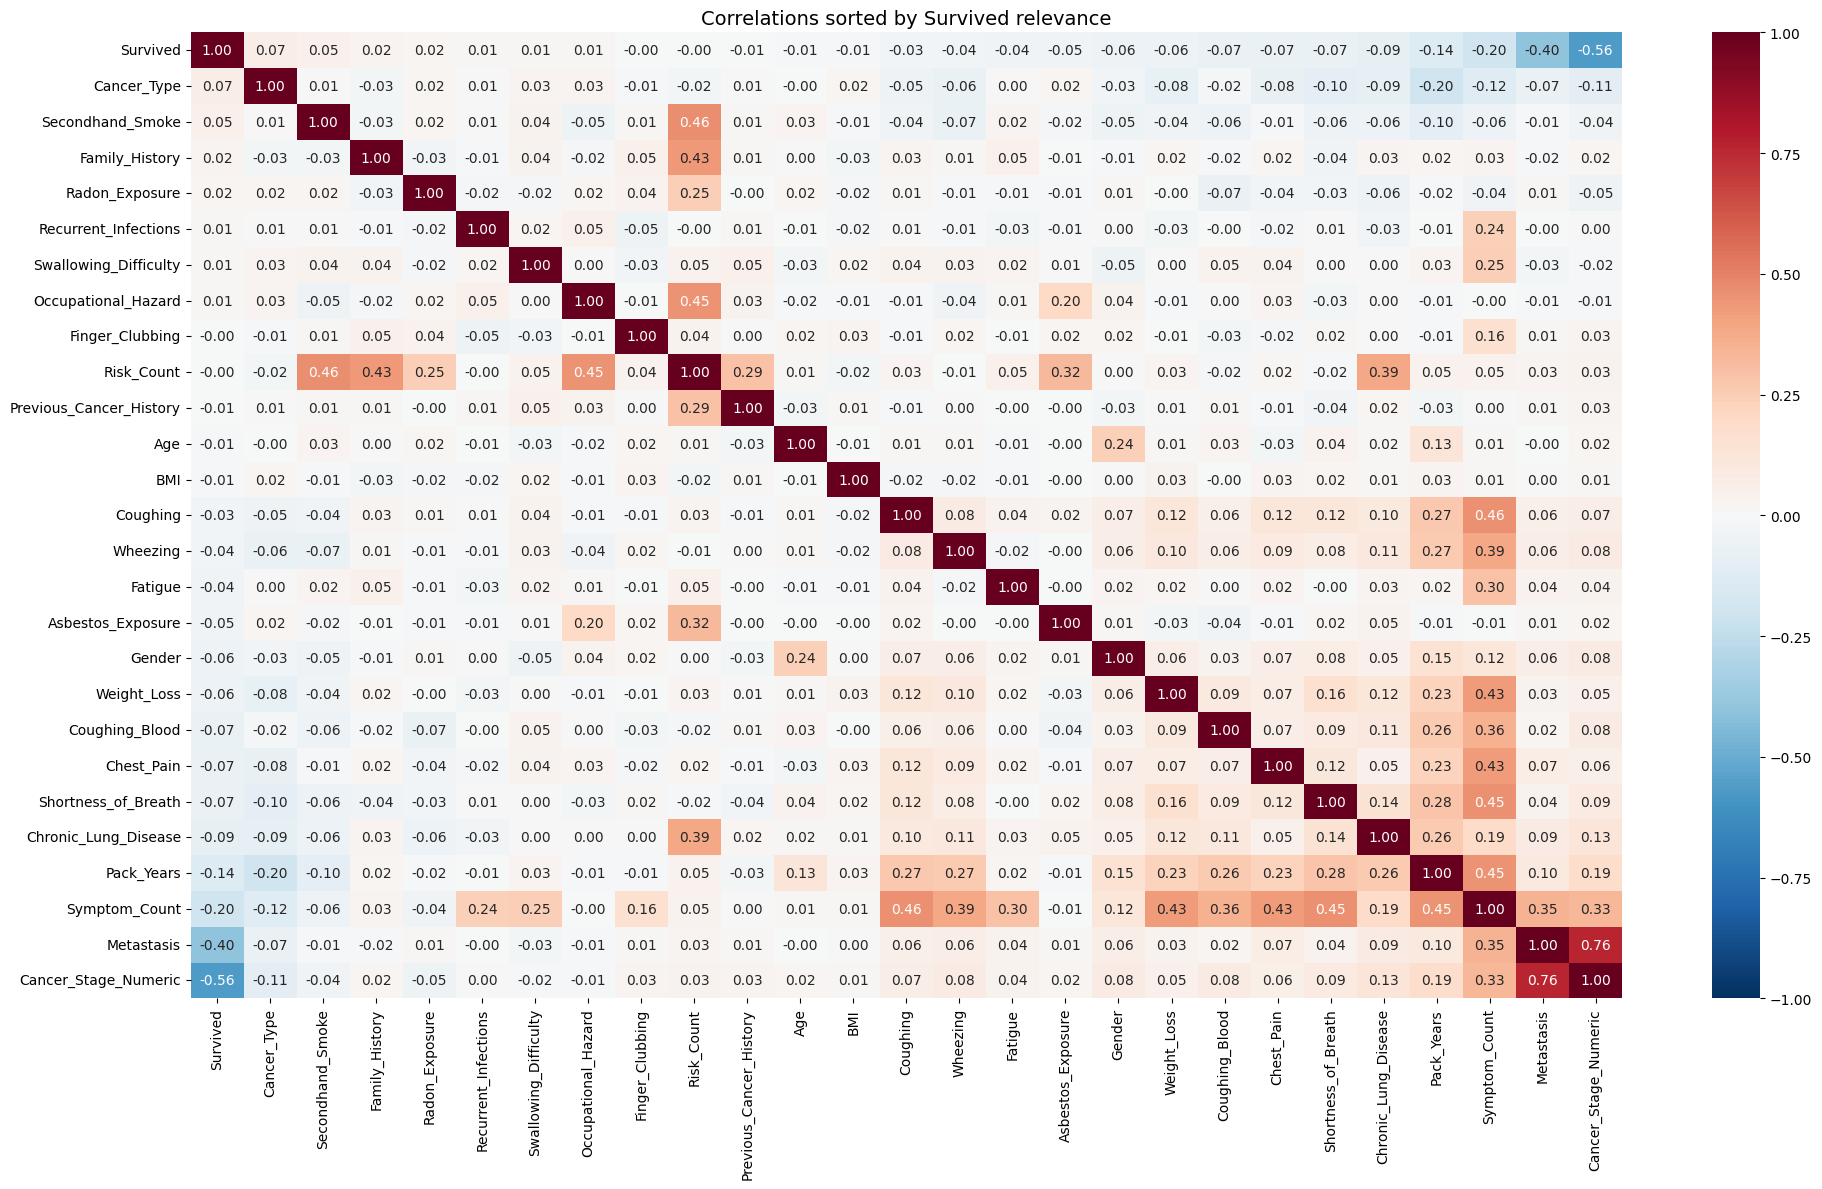

In [24]:
# Correlations sorted by relationship to Survived
corr = X.corr(numeric_only=True)
target_corr = corr['Survived'].sort_values(ascending=False)
sorted_cols = target_corr.index

corr_sorted = corr.loc[sorted_cols, sorted_cols]

plt.figure(figsize=(20, 12))
sns.heatmap(corr_sorted, 
            annot=True, 
            fmt='.2f',
            cmap='RdBu_r',  # Diverging: red=positive, blue=negative
            center=0,        # Center colormap at zero
            vmin=-1, 
            vmax=1)

plt.title('Correlations sorted by Survived relevance', fontsize=14)
plt.tight_layout()
plt.show()